Minimum cell count (562) is lower than size factor multiplier (1000)



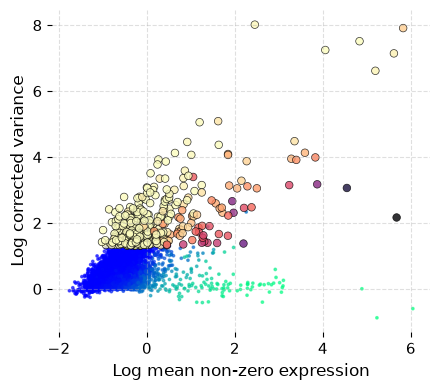

In [1]:
import scarf
import scarf.plotting as splt

scarf.set_verbosity('WARNING')

scarf.fetch_dataset('kang_15K_pbmc_rnaseq', save_path='scarf_datasets', as_zarr=True)
scarf.fetch_dataset('kang_14K_ifnb-pbmc_rnaseq', save_path='scarf_datasets', as_zarr=True)

ds_ctrl = scarf.DataStore('scarf_datasets/kang_15K_pbmc_rnaseq/data.zarr', nthreads=4)
ds_stim = scarf.DataStore('scarf_datasets/kang_14K_ifnb-pbmc_rnaseq/data.zarr', nthreads=4)

merged = 'scarf_datasets/kang_merged_pbmc_rnaseq.zarr'
scarf.AssayMerge(
    zarr_path=merged,
    assays=[ds_ctrl.RNA, ds_stim.RNA],
    names=['ctrl', 'stim'],
    merge_assay_name='RNA',
    overwrite=True,
).dump()

ds = scarf.DataStore(merged, nthreads=4)
ds.cells.insert(
    column_name='sample_id',
    values=[x.split('__')[0] for x in ds.cells.fetch_all('ids')],
    overwrite=True,
)
ds.cells.insert(
    column_name='imported_labels',
    values=list(ds_ctrl.cells.fetch_all('cluster_labels'))
    + list(ds_stim.cells.fetch_all('cluster_labels')),
    overwrite=True,
)
ds.mark_hvgs(min_cells=20, top_n=500)
ds.make_graph(feat_key='hvgs', k=11, dims=15, n_centroids=100)
ds.run_leiden_clustering(resolution=0.5)
ds.run_umap(n_epochs=100, parallel=True)

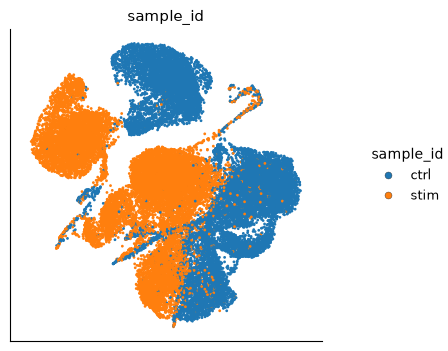

In [2]:
splt.embedding(
    ds,
    layout_key='RNA_UMAP',
    color_by='sample_id',
    show=False,
).figure;

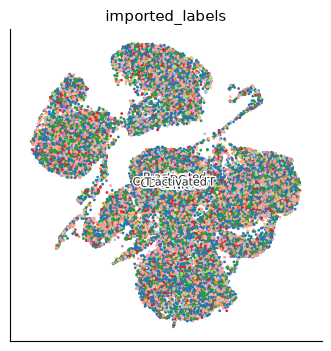

In [3]:
splt.embedding(
    ds,
    layout_key='RNA_UMAP',
    color_by='imported_labels',
    show=False,
).figure;

In [4]:
lisi = ds.metric_lisi(label_colnames=['sample_id'])
lisi

Perplexity 30 requires at least 90 neighbors, but the graph has 11. Using perplexity 3.66667.



[('sample_id',
  array([1.03323803, 1.10342121, 1.        , ..., 1.        , 1.        ,
         1.        ], shape=(29065,)))]

In [5]:
ds.metric_batch_mixing(label_colname='sample_id')

Perplexity 30 requires at least 90 neighbors, but the graph has 11. Using perplexity 3.66667.



0.03743231862929488

In [6]:
ds.metric_silhouette(res_label='leiden_cluster')

array([ 0.35142248,  0.5005044 ,  0.45794749,  0.5035922 , -0.04998804,
        0.1499605 , -0.0095266 ,  0.47621041, -0.0537269 ,  0.14107169,
        0.49794809,  0.45521678, -0.08805009,  0.60140825])

In [7]:
ds.metric_label_concordance(
    label_columns=['RNA_leiden_cluster', 'imported_labels']
)

0.00036094194402219536